In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
os.listdir('/kaggle/input')

['exam-score-prediction-dataset']

In [2]:
os.listdir('/kaggle/input/exam-score-prediction-dataset')

['Exam_Score_Prediction.csv']

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv')
df_model = df.drop(columns=['student_id'])

Mapping Ordinal Categorical Variables (where order matters)

In [6]:
ordinal_mappings = {'sleep_quality': {'poor': 0, 'average': 1, 'good': 2},'facility_rating': {'low': 0, 'medium': 1, 'high': 2},'exam_difficulty': {'easy': 0, 'moderate': 1, 'hard': 2}}

In [7]:
for col, mapping in ordinal_mappings.items():
    df_model[col] = df_model[col].map(mapping)
snehu_cols = ['gender', 'course', 'internet_access', 'study_method']
snehu = LabelEncoder()
for col in snehu_cols:
    df_model[col] = snehu.fit_transform(df_model[col])

In [20]:
X = df_model.drop(columns=['exam_score'])
y = df_model['exam_score']
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Model Performance Metrics")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (Accuracy): {r2:.4f}")

Model Performance Metrics
Mean Absolute Error (MAE): 7.99
Root Mean Squared Error (RMSE): 9.93
R-squared Score (Accuracy): 0.7243


Feature Importance

In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nKey Factors Influencing Exam Score")
print(importances)


Key Factors Influencing Exam Score
study_hours         0.684453
class_attendance    0.141837
sleep_quality       0.053685
study_method        0.046028
facility_rating     0.037543
sleep_hours         0.030212
age                 0.002060
course              0.001874
exam_difficulty     0.001063
gender              0.000856
internet_access     0.000388
dtype: float64


Graph

<Figure size 1000x600 with 0 Axes>

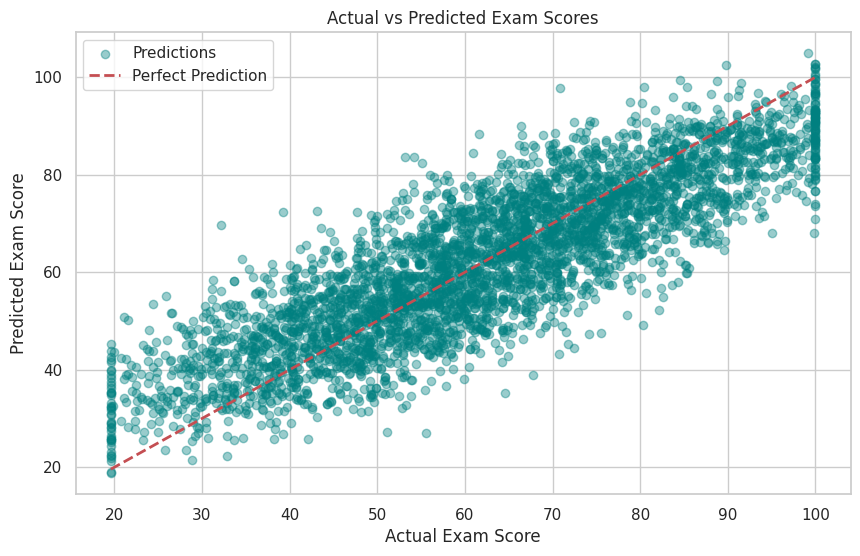

In [11]:
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(10,6))
#Graph1- Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.legend()
plt.savefig('actual_vs_predicted.png')

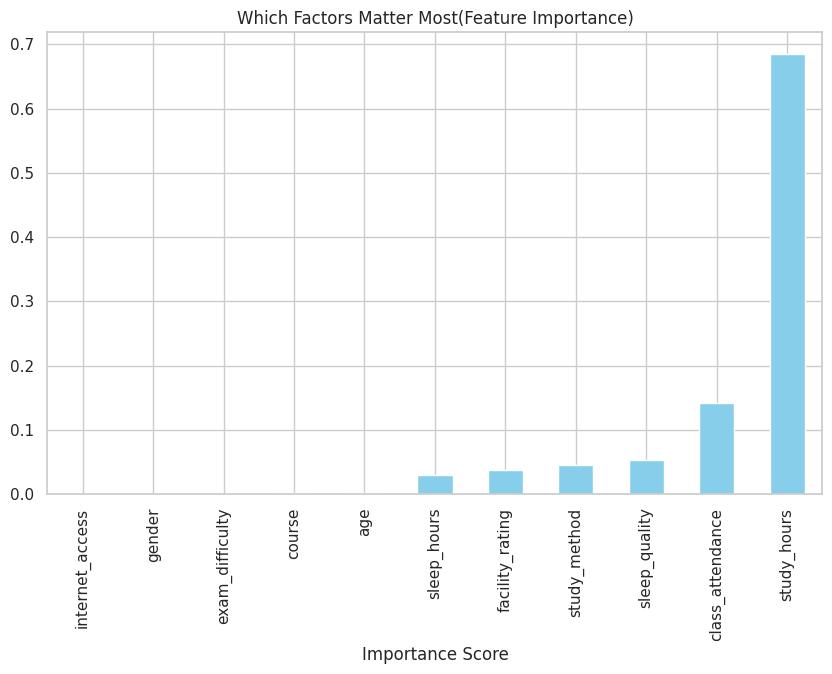

In [18]:
#Graph2- Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='skyblue')
plt.title('Which Factors Matter Most(Feature Importance)')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


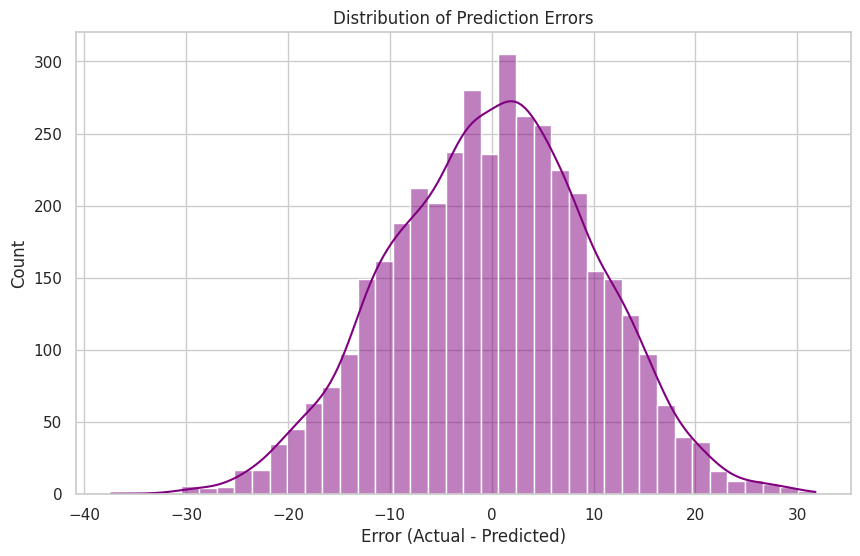

In [13]:
#Graph3- Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, color='purple')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.savefig('residuals_dist.png')

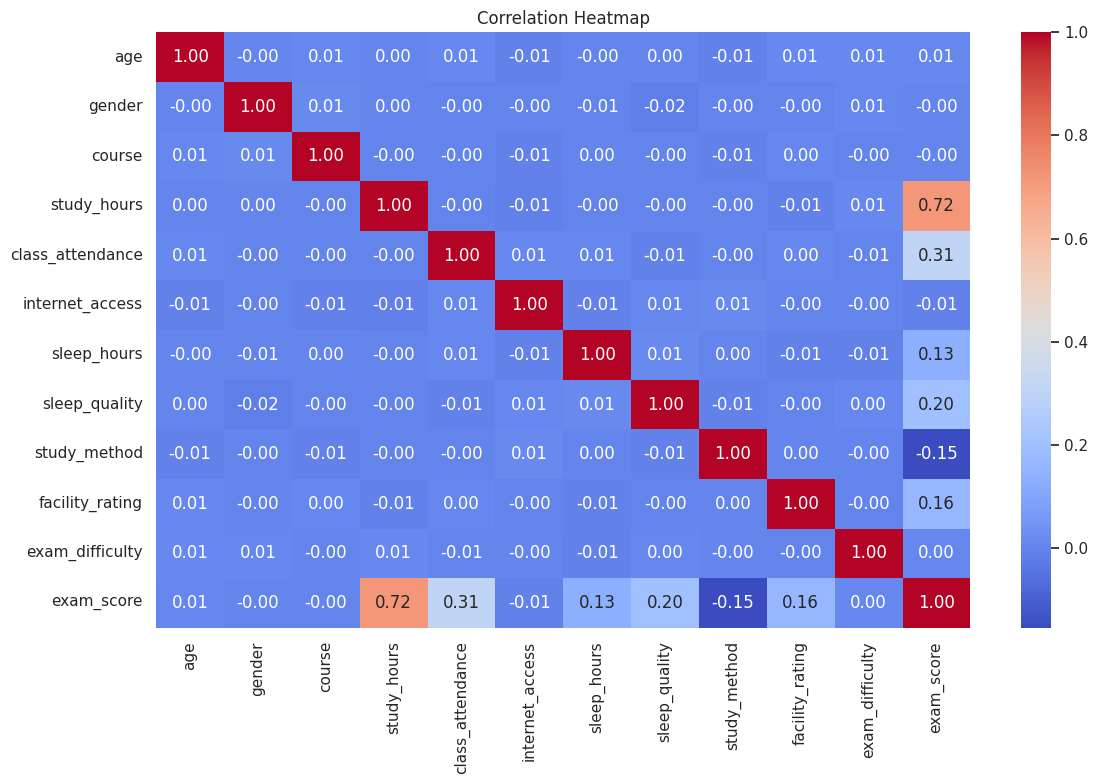

In [19]:
#Graph4- Correlation HeatMap
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')